In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# Load the dataset
df = pd.read_csv("cleaned_bearing_data.csv")

# Ensure dates are parsed
df['subscription_start'] = pd.to_datetime(df['subscription_start'])
df['timestamp_of_fault'] = pd.to_datetime(df['timestamp_of_fault'])

# Compute operational days
df['operational_days'] = (df['timestamp_of_fault'] - df['subscription_start']).dt.days

# Drop rows with missing or invalid fields
df = df.dropna(subset=['lubrication_method', 'operational_days', 'bearing_severity_class'])

# Clean method field
df['lubrication_method'] = df['lubrication_method'].replace("", "Not Available").fillna("Not Available")

# Optional: Filter extreme outliers
df = df[df['operational_days'] < 5000]  # Optional threshold


In [3]:
summary = df.groupby('lubrication_method').agg(
    count=('operational_days', 'count'),
    avg_life=('operational_days', 'mean'),
    median_life=('operational_days', 'median'),
    severity_mean=('bearing_severity_class', 'mean'),
    severity_0_rate=('bearing_severity_class', lambda x: (x == 0).sum() / len(x)),
    severity_3_rate=('bearing_severity_class', lambda x: (x == 3).sum() / len(x)),
).reset_index()
summary = summary[summary['count'] >= 10]
summary


,lubrication_method,count,avg_life,median_life,severity_mean,severity_0_rate,severity_3_rate
0,Drip Oil Feed Lubrication,40,468.400000,412.5,1.275000,0.400000,0.325000
1,Force Oil Feed Lubrication,24,400.958333,389.5,2.041667,0.166667,0.541667
2,Grease Lubrication,945,407.516402,404.0,1.183069,0.448677,0.293122
3,Not Available,6172,464.290830,418.0,1.064485,0.494491,0.251296
5,Self Lubrication,46,399.000000,388.0,1.543478,0.413043,0.478261
6,Shield/Sealed Bearing,34,354.029412,250.0,1.411765,0.411765,0.411765


In [4]:
# Lifespan test
groups = [group['operational_days'] for name, group in df.groupby('lubrication_method') if len(group) >= 10]
stat_life, p_life = kruskal(*groups)
print(f"Lubrication vs. Bearing Life — p = {p_life:.5f}")

# Severity test
severity_groups = [group['bearing_severity_class'] for name, group in df.groupby('lubrication_method') if len(group) >= 10]
stat_sev, p_sev = kruskal(*severity_groups)
print(f"Lubrication vs. Failure Severity — p = {p_sev:.5f}")


Lubrication vs. Bearing Life — p = 0.00029
Lubrication vs. Failure Severity — p = 0.00003


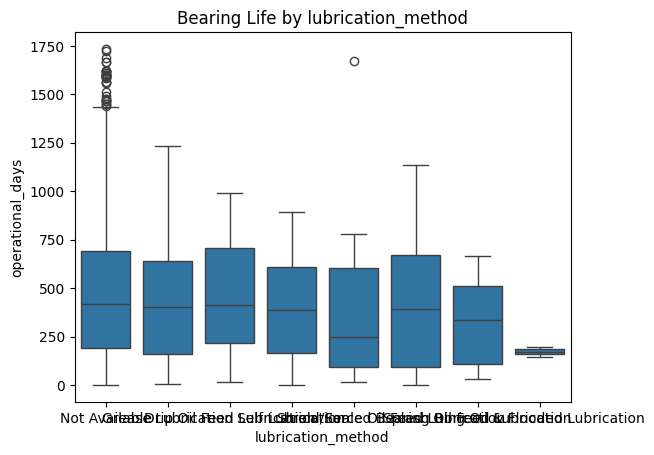

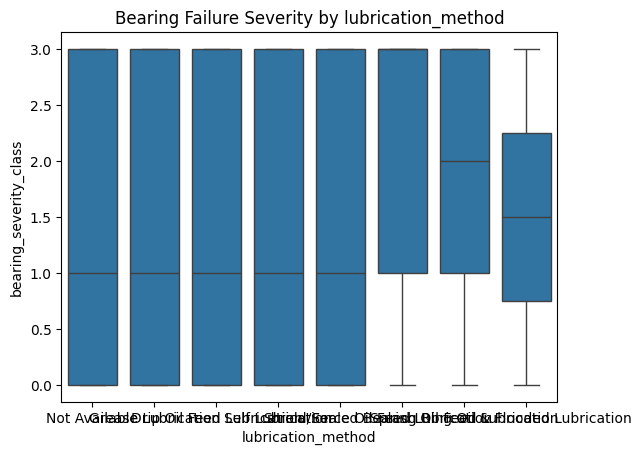

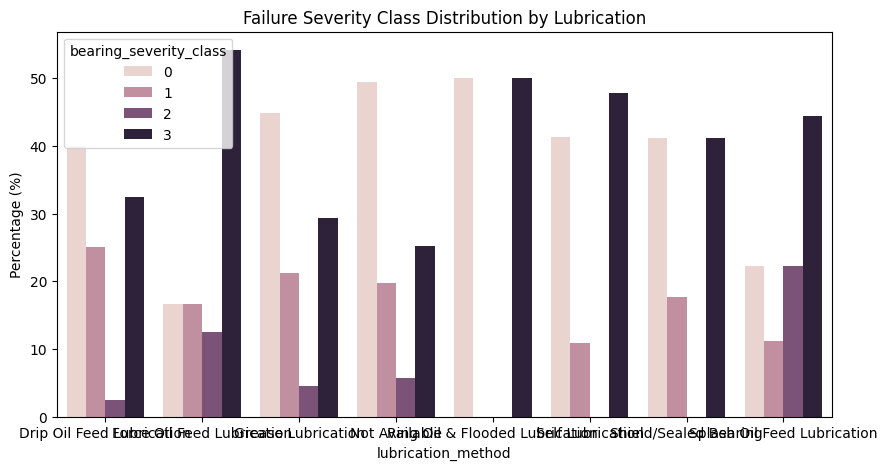

In [5]:
# Boxplot: Life vs Lubrication
sns.boxplot(x='lubrication_method', y='operational_days', data=df)
plt.title("Bearing Life by lubrication_method")
plt.show()

# Boxplot: Severity vs Lubrication
sns.boxplot(x='lubrication_method', y='bearing_severity_class', data=df)
plt.title("Bearing Failure Severity by lubrication_method")
plt.show()

# Heatmap-style bar: Severity Class distribution
severity_dist = df.groupby(['lubrication_method', 'bearing_severity_class']).size().reset_index(name='count')
severity_dist['percentage'] = severity_dist.groupby('lubrication_method')['count'].transform(lambda x: x / x.sum() * 100)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=severity_dist,
    x='lubrication_method',
    y='percentage',
    hue='bearing_severity_class'
)
plt.title("Failure Severity Class Distribution by Lubrication")
plt.ylabel("Percentage (%)")
plt.show()


In [7]:
summary.to_csv("outputs/q4/lubrication_summary.csv", index=False)


In [ ]:
# Step 1: Count severity class per lubrication_method
severity_dist = df.groupby(['lubrication_method', 'bearing_severity_class']).size().reset_index(name='count')

# Step 2: Normalize to percentage within each lubrication_method
severity_dist['percentage'] = severity_dist.groupby('lubrication_method')['count'].transform(
    lambda x: x / x.sum() * 100
)

# Optional: Round for display
severity_dist['percentage'] = severity_dist['percentage'].round(2)

# Step 3: Save to CSV for streamlit app
severity_dist.to_csv("exploration/outputs/q4/lubrication_severity_distribution.csv", index=False)


KeyError: 'Lubrication Method'